In [2]:
import pandas as pd
import matplotlib.pyplot as plt

customer_data = pd.read_csv('data/customer_data.csv')
order_data = pd.read_csv('data/order_data.csv')

order_data.head(20)

,Order Id,Order Date,Ship Mode,Segment,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent,Customer ID
0,1,01-03-2023,Second Class,Consumer,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2,782
1,2,15-08-2023,Second Class,Consumer,Furniture,Chairs,FUR-CH-10000454,600,730,3,3,2827
2,3,10-01-2023,Second Class,Corporate,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5,1806
3,4,18-06-2022,Standard Class,Consumer,Furniture,Tables,FUR-TA-10000577,780,960,5,2,1642
4,5,13-07-2022,Standard Class,Consumer,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5,1349
5,6,13-03-2022,Not Available,Consumer,Furniture,Furnishings,FUR-FU-10001487,50,50,7,3,4993
6,7,28-12-2022,Standard Class,Consumer,Office Supplies,Art,OFF-AR-10002833,10,10,4,3,1433
7,8,25-01-2022,Standard Class,Consumer,Technology,Phones,TEC-PH-10002275,860,910,6,5,2231
8,9,23-03-2023,Not Available,Consumer,Office Supplies,Binders,OFF-BI-10003910,20,20,3,2,3199
9,10,16-05-2023,Standard Class,Consumer,Office Supplies,Appliances,OFF-AP-10002892,90,110,5,3,1993


In [3]:
customer_data.columns = (
    customer_data.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^a-z0-9]+', '_', regex=True)
    .str.strip('_')
)

order_data.columns = (
    order_data.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^a-z0-9]+', '_', regex=True)
    .str.strip('_')
)

In [4]:
print("=== customer_data: duplicate rows found ===")
print(customer_data.duplicated().sum())

before = len(customer_data)
customer_data = customer_data.drop_duplicates()
print(f"customer_data: dropped {before - len(customer_data)} duplicate rows")

=== customer_data: duplicate rows found ===
50
customer_data: dropped 50 duplicate rows


In [5]:
print("customer_data unique season values")
print(customer_data['season'].unique())

print("customer_data null counts")
print(customer_data.isnull().sum()[customer_data.isnull().sum() > 0])


customer_data unique season values
<ArrowStringArray>
['Winter', 'Spring', 'Fall', 'Summer', 'Autumn']
Length: 5, dtype: str
customer_data null counts
purchase_amount_usd    558
size                   374
review_rating          600
discount_applied         2
previous_purchases     548
dtype: int64


In [6]:
customer_data['season'] = customer_data['season'].replace({'Autumn': 'Fall'})
print(customer_data['season'].unique())

<ArrowStringArray>
['Winter', 'Spring', 'Fall', 'Summer']
Length: 4, dtype: str


purchase_amount_usd: skew = 3.322, mean = 145.73, median = 65.00
previous_purchases: skew = 0.004, mean = 25.23, median = 25.00
review_rating: skew = -0.608, mean = 3.67, median = 3.70


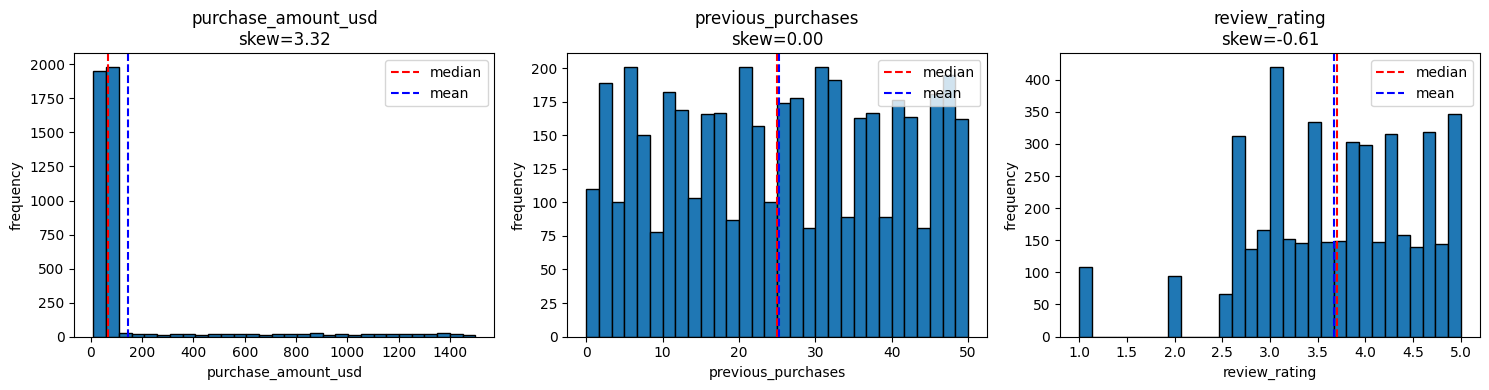

In [7]:
for col in ['purchase_amount_usd', 'previous_purchases', 'review_rating']:
    print(f"{col}: skew = {customer_data[col].skew():.3f}, mean = {customer_data[col].mean():.2f}, median = {customer_data[col].median():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cols = ['purchase_amount_usd', 'previous_purchases', 'review_rating']

for ax, col in zip(axes, cols):
    ax.hist(customer_data[col].dropna(), bins=30, edgecolor='black')
    ax.axvline(customer_data[col].median(), color='red', linestyle='--', label='median')
    ax.axvline(customer_data[col].mean(), color='blue', linestyle='--', label='mean')
    ax.set_title(f"{col}\nskew={customer_data[col].skew():.2f}")
    ax.set_xlabel(col)
    ax.set_ylabel('frequency')
    ax.legend()

plt.tight_layout()
plt.show()

In [8]:
for col in ['purchase_amount_usd', 'previous_purchases', 'review_rating']:
    median_val = customer_data[col].median()
    n_missing = customer_data[col].isnull().sum()
    customer_data[col] = customer_data[col].fillna(median_val)
    print(f"customer_data.{col}: imputed {n_missing} nulls with median={median_val}")

customer_data.purchase_amount_usd: imputed 558 nulls with median=65.0
customer_data.previous_purchases: imputed 548 nulls with median=25.0
customer_data.review_rating: imputed 600 nulls with median=3.7


In [9]:
n_size_missing = customer_data['size'].isnull().sum()
customer_data['size'] = customer_data['size'].fillna('Unknown')
print(f"customer_data.size: filled {n_size_missing} nulls with 'Unknown'")

mode_discount = customer_data['discount_applied'].mode()[0]
n_discount_missing = customer_data['discount_applied'].isnull().sum()
customer_data['discount_applied'] = customer_data['discount_applied'].fillna(mode_discount)
print(f"customer_data.discount_applied: filled {n_discount_missing} nulls with mode='{mode_discount}'")

customer_data.size: filled 374 nulls with 'Unknown'
customer_data.discount_applied: filled 2 nulls with mode='No'


In [10]:
print("\n=== order_data: duplicate rows ===")
print(order_data.duplicated().sum())

print("\n=== order_data: null counts ===")
print(order_data.isnull().sum()[order_data.isnull().sum() > 0])

print("\n=== order_data: order_date sample (before parsing) ===")
print(order_data['order_date'].head(10).tolist())


=== order_data: duplicate rows ===
0

=== order_data: null counts ===
ship_mode    1
dtype: int64

=== order_data: order_date sample (before parsing) ===
['01-03-2023', '15-08-2023', '10-01-2023', '18-06-2022', '13-07-2022', '13-03-2022', '28-12-2022', '25-01-2022', '23-03-2023', '16-05-2023']


In [11]:
mode_ship = order_data['ship_mode'].mode()[0]
order_data['ship_mode'] = order_data['ship_mode'].fillna(mode_ship)

order_data['order_date'] = pd.to_datetime(order_data['order_date'], format='%d-%m-%Y')


In [12]:
print("\ncustomer_data nulls after cleaning:")
print(customer_data.isnull().sum()[customer_data.isnull().sum() > 0])

print("\norder_data nulls after cleaning:")
print(order_data.isnull().sum()[order_data.isnull().sum() > 0])

print("\nFinal shapes:", customer_data.shape, order_data.shape)


customer_data nulls after cleaning:
Series([], dtype: int64)

order_data nulls after cleaning:
Series([], dtype: int64)

Final shapes: (5000, 14) (9994, 12)


In [13]:
print("cost_price range:", order_data['cost_price'].min(), "-", order_data['cost_price'].max())
print("list_price range:", order_data['list_price'].min(), "-", order_data['list_price'].max())
print("quantity range:", order_data['quantity'].min(), "-", order_data['quantity'].max())
print("discount_percent range:", order_data['discount_percent'].min(), "-", order_data['discount_percent'].max())
print("order_date range:", order_data['order_date'].min(), "-", order_data['order_date'].max())

invalid_orders = order_data[
    (order_data['cost_price'] < 0) |
    (order_data['list_price'] < 0) |
    (order_data['quantity'] <= 0) |
    (order_data['discount_percent'] < 0) | (order_data['discount_percent'] > 100) |
    (order_data['cost_price'] > order_data['list_price'])
]
print(f"\nRows with logically invalid values: {len(invalid_orders)}")

print("Rows with cost_price == 0:", (order_data['cost_price'] == 0).sum())
print("Rows with list_price == 0:", (order_data['list_price'] == 0).sum())

cost_price range: 0 - 18110
list_price range: 0 - 22640
quantity range: 1 - 14
discount_percent range: 2 - 5
order_date range: 2022-01-01 00:00:00 - 2023-12-31 00:00:00

Rows with logically invalid values: 0
Rows with cost_price == 0: 507
Rows with list_price == 0: 507


In [14]:
# Validity checks instead of outlier removal
print("age range:", customer_data['age'].min(), "-", customer_data['age'].max())
print("purchase_amount_usd range:", customer_data['purchase_amount_usd'].min(), "-", customer_data['purchase_amount_usd'].max())
print("review_rating range:", customer_data['review_rating'].min(), "-", customer_data['review_rating'].max())
print("previous_purchases range:", customer_data['previous_purchases'].min(), "-", customer_data['previous_purchases'].max())

# Flag anything logically impossible (negative amounts, rating outside 1-5, negative age, etc.)
invalid = customer_data[
    (customer_data['purchase_amount_usd'] < 0) |
    (customer_data['review_rating'] < 1) | (customer_data['review_rating'] > 5) |
    (customer_data['age'] < 0) | (customer_data['age'] > 100)
]
print(f"\nRows with logically invalid values: {len(invalid)}")

age range: 18 - 70
purchase_amount_usd range: 10.12 - 1499.76
review_rating range: 1.0 - 5.0
previous_purchases range: 0.0 - 50.0

Rows with logically invalid values: 0


In [15]:
# Impute zero prices using the same product's known price elsewhere
price_lookup = (
    order_data[~((order_data['cost_price']==0) & (order_data['list_price']==0))]
    .groupby('product_id')[['cost_price','list_price']]
    .median()
)

zero_mask = (order_data['cost_price']==0) & (order_data['list_price']==0)

order_data.loc[zero_mask, 'cost_price'] = order_data.loc[zero_mask, 'product_id'].map(price_lookup['cost_price'])
order_data.loc[zero_mask, 'list_price'] = order_data.loc[zero_mask, 'product_id'].map(price_lookup['list_price'])

# Check how many are still unresolved (product_id never had a real price anywhere)
still_zero = order_data[(order_data['cost_price']==0) | (order_data['cost_price'].isnull())]
print(f"Rows still unresolved after imputation: {len(still_zero)}")

Rows still unresolved after imputation: 21


In [16]:
customer_data.to_csv('data/customer_data_cleaned.csv', index=False)
order_data.to_csv('data/order_data_cleaned.csv', index=False)
print('Exported cleaned datasets:')
print(' - data/customer_data_cleaned.csv')
print(' - data/order_data_cleaned.csv')

Exported cleaned datasets:
 - data/customer_data_cleaned.csv
 - data/order_data_cleaned.csv
